Noise analysis with our own function that does the Trotter method

Things to analyse 
- Gate noise
- Hardware noise
- Qubit noise
- Bias noise models?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import functools as ft
import scipy as sp

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector, Operator, Pauli
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import SuzukiTrotter
from qiskit.primitives import StatevectorEstimator
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from scipy.optimize import minimize
from qiskit import transpile

### Hugos trotter method below (couldnt figure out how to import ipynb file)

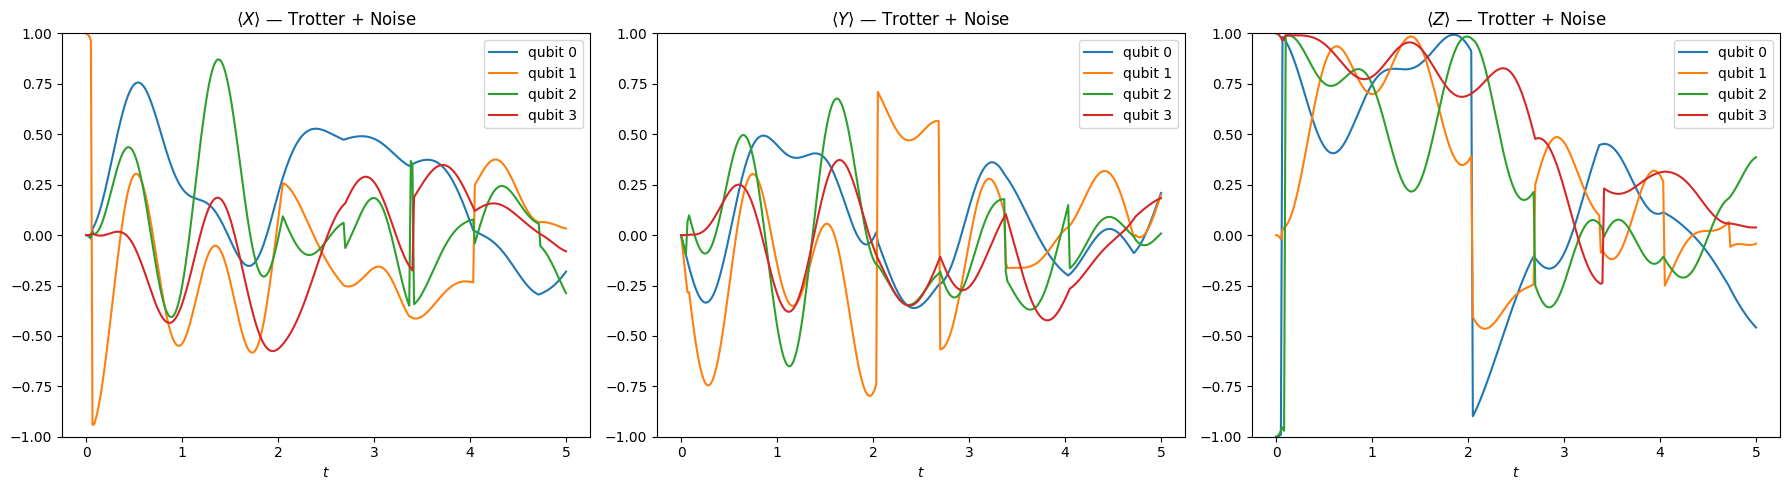

In [3]:
def hamiltonian1(L, Jz):
    """
    Docstring for hamiltonian
    
    :param X: X pauli op
    (X, 0, t)
    :param Y: Y pauli op
    :param Z: Z pauli op
    """
    ham_list = []

    for i in range (int(L)-1):
        ham_list.append(("XX", [i, i+1], -1)) # XX bc Xi and X i+1
        ham_list.append(("YY", [i, i+1], -1))
        ham_list.append(("ZZ", [i, i+1], -Jz))

    H =  SparsePauliOp.from_sparse_list(ham_list, num_qubits=L)

    return H

def initialise(Jz, L, allzeros=True, rotate_middle=True):
    """
    Return the initial Statevector for the given Jz regime.

    :param Jz: (float) anisotropy; must satisfy |Jz| > 1
    :param L:  (int) number of qubits
    :param allzeros: (bool)  for Jz > 1: True → |000…⟩, False → |111…⟩
    :param rotate_middle:(bool) if True, apply Ry(π/2) to qubit L//2
    :returns:            Statevector of the initial state
    """
    if Jz > 1:
        if allzeros:
            sv = Statevector.from_label("0" * L)
        else:
            sv = Statevector.from_label("1" * L)
    elif Jz < -1:
        alternating = "".join(["10"[i % 2] for i in range(L)])
        sv = Statevector.from_label(alternating)
    else:
        raise ValueError("Jz must be > 1 or < -1")

    #rotation is done at this atge bc trotter method can work with it out this function but mchlachan cannot
    if rotate_middle:
        middle = L // 2
        qc_rot = QuantumCircuit(L)
        qc_rot.ry(np.pi / 2, middle)
        sv = sv.evolve(Operator(qc_rot))   

    return sv

pauli_x  = np.array([[0,  1 ], [1,   0]], dtype=complex)
pauli_y  = np.array([[0, -1j], [1j,  0]], dtype=complex)
pauli_z  = np.array([[1,  0 ], [0,  -1]], dtype=complex)
identity = np.eye(2, dtype=complex)

def observable_matrix(L, qubit, pauli):
    """Full 2^L × 2^L matrix for a single-site Pauli operator."""
    ops = [identity] * L
    ops[qubit] = pauli
    return ft.reduce(np.kron, ops)

def expectation_value(psi, obs):
    return np.real(np.vdot(psi, obs @ psi))

def trotter_step_1st_order(circuit, H, dt):
    """
    Apply a single 1st-order Trotter step to a QuantumCircuit.

    :param circuit: QuantumCircuit to append gates to
    :param H:       SparsePauliOp Hamiltonian
    :param dt:      timestep size
    :returns:       updated circuit
    """
    for pauli_str, coeff in H.to_list():
        pauli_op = Pauli(pauli_str)
        gate = PauliEvolutionGate(pauli_op, time=dt * coeff.real)
        circuit.append(gate, range(circuit.num_qubits))
    return circuit

def first_order_trotter(H, t, n_steps, num_qubits=None):
    """
    Build a circuit implementing first-order Trotterised time evolution.

    :param H:          SparsePauliOp Hamiltonian
    :param t:          total evolution time
    :param n_steps:    number of Trotter steps
    :param num_qubits: system size (inferred from H if None)
    :returns:          QuantumCircuit
    """
    if num_qubits is None:
        num_qubits = H.num_qubits
    qc = QuantumCircuit(num_qubits)
    dt = t / n_steps
    for _ in range(n_steps):
        trotter_step_1st_order(qc, H, dt)
    return qc


def trotter_with_noise(L, Jz, steps, t_tot, error_rate=0.01, allzeros=True):
        H  = hamiltonian1(L, Jz)
        dt = t_tot / steps

        noise_model = NoiseModel()
        error_2q    = depolarizing_error(error_rate, 2)
        noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])

        psi0 = initialise(Jz, L, allzeros=allzeros, rotate_middle=True)

        simulator = AerSimulator(method='statevector', noise_model=noise_model)
        states    = [np.array(psi0)]
        current_sv = np.array(psi0)

        # Build and transpile a single Trotter step once
        qc_step = QuantumCircuit(L)
        trotter_step_1st_order(qc_step, H, dt)
        qc_step = transpile(qc_step, simulator)

        for _ in range(steps):
            qc_run = QuantumCircuit(L)
            qc_run.initialize(current_sv)
            qc_run = qc_run.compose(qc_step)
            qc_run.save_statevector()
            result = simulator.run(qc_run).result()
            current_sv = result.get_statevector().data
            states.append(current_sv)

        return states


L, Jz, steps, t_tot = 4, -1.1, 300, 5.0
noisy_states = trotter_with_noise(L, Jz, steps, t_tot, error_rate=0.005)
t_values     = np.arange(len(noisy_states)) * (t_tot / steps)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, pauli_mat, label in zip(axes, [pauli_x, pauli_y, pauli_z], ['X','Y','Z']):
    for q in range(L):
        obs  = observable_matrix(L, q, pauli_mat)
        vals = [expectation_value(psi, obs) for psi in noisy_states]
        ax.plot(t_values, vals, label=f'qubit {q}')
    ax.set_title(rf'$\langle {label} \rangle$ — Trotter + Noise')
    ax.set_xlabel(r'$t$')
    ax.set_ylim(-1, 1)
    ax.legend()
plt.tight_layout()
plt.show()